# <center>Si ustedes fueran a invertir en un Airbnb en alguna ciudad,</center>  
# <center> ¿qué información necesitarían antes de decidir?</center>

## Análisis de hosts y sus propiedades


In [1]:
# Cargar los archivos CSV en DataFrames
import pandas as pd 
airbnb = pd.read_csv('../Cambridge.csv')

In [2]:
airbnb.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,8521,https://www.airbnb.com/rooms/8521,20241228025327,2024-12-28,previous scrape,SunsplashedSerenity walk to Harvard & Fresh Pond,"An elegant, sun-splashed, 2 bedroom (+2offices...",Huron Village is known for its charm. We have...,https://a0.muscache.com/pictures/30536/072e0a5...,306681,...,4.92,4.93,4.74,C0121120491,f,2,2,0,0,0.40
1,11169,https://www.airbnb.com/rooms/11169,20241228025327,2024-12-28,previous scrape,Lovely Studio Room: Available for long w/ends,Large sunny room w kitchenette & bath. Foam ma...,The neighborhood is quiet and friendly and our...,https://a0.muscache.com/pictures/miso/Hosting-...,40965,...,4.92,4.79,4.76,NaN,f,3,1,2,0,1.02
2,19581,https://www.airbnb.com/rooms/19581,20241228025327,2024-12-28,city scrape,"Furnished suite, Windsor","Welcome to Area IV! We are located, convenient...",NaN,https://a0.muscache.com/pictures/188f1b4b-f37b...,74249,...,4.90,4.90,4.30,NaN,t,3,0,3,0,0.07
3,27498,https://www.airbnb.com/rooms/27498,20241228025327,2024-12-28,city scrape,Furnished suite 2 @ the Windsor,"Welcome to Area IV! We are located, convenient...",NaN,https://a0.muscache.com/pictures/bab30c3c-ff3c...,74249,...,4.75,4.88,4.63,NaN,t,3,0,3,0,0.15
4,79762,https://www.airbnb.com/rooms/79762,20241228025327,2024-12-28,city scrape,Cambridge Getaway @ Harvard & MIT,Charming 2-bedroom apartment on the third floo...,Annmarie and I have lived in this area for ove...,https://a0.muscache.com/pictures/airflow/Hosti...,430015,...,4.93,4.93,4.76,STR-15661,f,1,1,0,0,2.61


¿qué tipo de alojamiento predomina?

In [3]:
airbnb["room_type"].value_counts()

room_type
Entire home/apt    687
Private room       545
Hotel room          54
Shared room          1
Name: count, dtype: int64

¿Cuál es el tipo de alojamiento más común en Cambridge?

"Ya sabemos qué tipo de alojamiento aparece más. Pero ahora quiero saber cuánto cuesta, en promedio, cada tipo."

In [4]:
airbnb.groupby("room_type")["price"].mean()

TypeError: agg function failed [how->mean,dtype->object]

In [5]:
airbnb["price"].dtype
airbnb["price"].head()

0        NaN
1        NaN
2    $172.00
3    $201.00
4    $300.00
Name: price, dtype: object

In [6]:
airbnb["price"] = (
    airbnb["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [7]:
print(airbnb["price"].isna().sum())

342


In [8]:
precio_tipo = (
    airbnb
    .groupby("room_type")["price"]
    .agg(["count", "mean", "min", "max"])
)
print(precio_tipo)

                 count        mean    min     max
room_type                                        
Entire home/apt    509  230.557957   21.0  1500.0
Hotel room          13  343.615385  319.0   399.0
Private room       423   91.238771   10.0   874.0
Shared room          0         NaN    NaN     NaN


¿Qué tipo de alojamiento tiene el precio promedio más alto?

In [13]:
precio_tipo["mean"].idxmax()

'Hotel room'

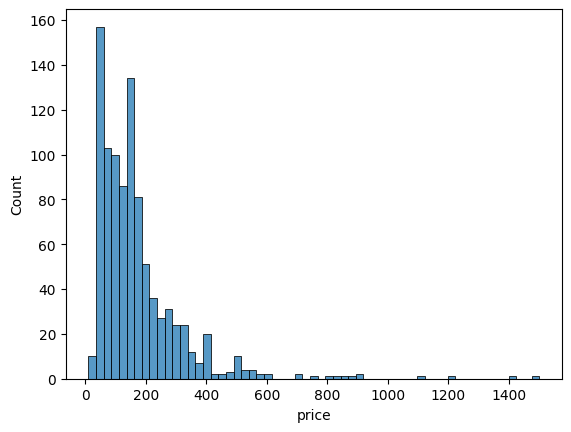

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=airbnb, x="price")
plt.show()

¿Qué observan?



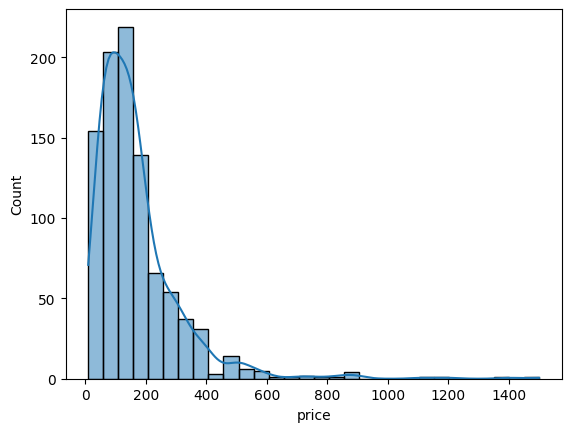

In [18]:
sns.histplot(data=airbnb, x="price", bins=30, kde=True)
plt.show()

Si cambio bins, ¿cambiaron los datos?


## Ejercicio 1: ¿Cuántas propiedades tiene cada host?
Usa groupby() y merge() para unir la información de hosts y calcular cuántas propiedades administra cada uno.

In [19]:
hosts = airbnb[['host_id', 'host_name', 'host_since', 'host_is_superhost', 'host_listings_count']]
listings = airbnb[['host_id', 'id', 'name', 'property_type', 'room_type', 'price']]
print(hosts)
print(listings)





        host_id       host_name  host_since host_is_superhost  \
0        306681           Janet  2010-12-01                 t   
1         40965        Judith L  2009-09-24                 t   
2         74249  Marc And Patty  2010-01-27                 t   
3         74249  Marc And Patty  2010-01-27                 t   
4        430015           Kevin  2011-03-08                 t   
...         ...             ...         ...               ...   
1282  373675137            Liya  2020-10-28                 f   
1283  373675137            Liya  2020-10-28                 f   
1284  373675137            Liya  2020-10-28                 f   
1285  145655051           Karen  2017-08-12                 t   
1286  373675137            Liya  2020-10-28                 f   

      host_listings_count  
0                       2  
1                       4  
2                       3  
3                       3  
4                       1  
...                   ...  
1282                  2

In [21]:
df_host = pd.merge(hosts, listings, on="host_id", how="left")
df_host

,host_id,host_name,host_since,host_is_superhost,host_listings_count,id,name,property_type,room_type,price
0,306681,Janet,2010-12-01,t,2,8521,SunsplashedSerenity walk to Harvard & Fresh Pond,Entire rental unit,Entire home/apt,NaN
1,306681,Janet,2010-12-01,t,2,108898,"""The Treehouse"" : Elegant living near Harvard",Entire rental unit,Entire home/apt,NaN
2,40965,Judith L,2009-09-24,t,4,11169,Lovely Studio Room: Available for long w/ends,Private room in condo,Private room,NaN
3,40965,Judith L,2009-09-24,t,4,1080789,Entire Fabulous home: Available occasionally!,Entire condo,Entire home/apt,NaN
4,40965,Judith L,2009-09-24,t,4,17693766,Grad Student or Professor!,Private room in home,Private room,NaN
...,...,...,...,...,...,...,...,...,...,...
44064,373675137,Liya,2020-10-28,f,217,1308846162056102099,Great 1Bedroom in Boston,Private room in rental unit,Private room,46.0
44065,373675137,Liya,2020-10-28,f,217,1313250609203710870,Very comfortable 1 bedroom in Boston,Private room in rental unit,Private room,61.0
44066,373675137,Liya,2020-10-28,f,217,1313277221998634744,Peacefull 1 bedroom in Boston,Private room in rental unit,Private room,44.0
44067,373675137,Liya,2020-10-28,f,217,1313301960513049198,Comfortable 1 Bedroom in Boston,Private room in rental unit,Private room,46.0


In [23]:
# Contar cuántas propiedades tiene cada host
df_host_count = df_host.groupby(['host_id', 'host_name', 'host_is_superhost'])['id'].count().reset_index()
print(f"Número de propiedades por host: \n{df_host_count}")
df_host_count.rename(columns={'id': 'num_listings'}, inplace=True)

print(f"Número de propiedades por host: \n")
df_host_count.sort_values(
    "num_listings",
    ascending=False
).head(10)

Número de propiedades por host: 
       host_id                       host_name host_is_superhost   id
0        40965                        Judith L                 t    9
1        69838                            Mara                 f    1
2        74249                  Marc And Patty                 t    9
3        81038                          Louisa                 t   81
4        87398                             Ari                 f    1
..         ...                             ...               ...  ...
415  653636057                           Shane                 f   49
416  657466767                          Aishat                 f  676
417  657804004                          Janesh                 f   16
418  661669372                           Belen                 f    1
419  666372838  Fairfield Inn Suites Boston Ca                 f    1

[420 rows x 4 columns]
Número de propiedades por host: 



,host_id,host_name,host_is_superhost,num_listings
282,107434423,Blueground,f,27225
355,373675137,Liya,f,4624
218,43450256,Steve,f,3721
356,380623623,Sofia,t,784
387,501999514,RoomPicks,f,784
416,657466767,Aishat,f,676
237,51079261,Riverside,t,529
303,162885740,Hong,f,529
330,229497500,Yudong,f,484
377,463475392,Haroldo,t,484


¿Quien administra más propiedades?

## ¿Cuáles son los superhosts más activos?
Filtra solo los superhosts (host_is_superhost == 't') y ordena por número de propiedades.

In [ ]:
superhosts = df_host_count[df_host_count['host_is_superhost'] == 't']
print(f"Superhosts: \n{superhosts}")
superhosts = superhosts.sort_values(by='num_listings', ascending=False)
print("Los 10 superhosts más activos: \n ")  # Los 10 superhosts más 
superhosts.head(10)




Superhosts: 
       host_id       host_name host_is_superhost  num_listings
0        40965        Judith L                 t             9
2        74249  Marc And Patty                 t             9
3        81038          Louisa                 t            81
7       306681           Janet                 t             4
8       404360          Victor                 t             1
..         ...             ...               ...           ...
406  579486959           Yujia                 t             4
407  579647560          Zainab                 t             1
408  584853621          Pinyen                 t            25
409  585523189          Belter                 t             9
412  593833353          Meryem                 t             1

[170 rows x 4 columns]
Los 10 superhosts más activos: 
 


,host_id,host_name,host_is_superhost,num_listings
356,380623623,Sofia,t,784
237,51079261,Riverside,t,529
377,463475392,Haroldo,t,484
160,22541573,Furnished Quarters,t,441
86,7848820,Kris,t,256
153,21631889,Ling Yi,t,121
131,16241860,Isabel,t,121
225,45011296,Lance,t,100
3,81038,Louisa,t,81
328,222601907,Angel,t,49


¿Los hosts con más propiedades son superhosts?

## Análisis de precios y tipos de propiedades
Ahora combinaremos datos de precios, tipos de propiedades y ubicación para descubrir tendencias de precios.

¿Cuál es el precio promedio por tipo de propiedad?

In [26]:
df_price_type = airbnb.groupby("property_type")["price"].mean().reset_index()
df_price_type.sort_values(by="price", ascending=False, inplace=True)

print(f"Precio promedio por tipo de propiedad: \n{df_price_type}")

Precio promedio por tipo de propiedad: 
                         property_type       price
8                     Entire townhouse  477.000000
3                          Entire home  390.333333
9                         Entire villa  345.000000
2                    Entire guesthouse  250.000000
7            Entire serviced apartment  236.100000
0                         Entire condo  226.527778
21                       Room in hotel  222.200000
6                   Entire rental unit  209.112245
4                          Entire loft  199.666667
20              Room in boutique hotel  186.240000
1                   Entire guest suite  167.833333
14             Private room in cottage  150.000000
5                         Entire place  149.000000
11   Private room in bed and breakfast  148.866667
13               Private room in condo  129.625000
18  Private room in serviced apartment  113.000000
15         Private room in guest suite  112.000000
19           Private room in townhouse  10

 ¿Qué barrios son más caros?

In [34]:
df_price_neigh = airbnb.groupby("neighbourhood_cleansed")["price"].max().reset_index()
df_price_neigh.sort_values(by="price", ascending=False, inplace=True)
print(f"Los 10 barrios más caros: \n{df_price_neigh.head(10)}")

Los 10 barrios más caros: 
   neighbourhood_cleansed   price
11  Wellington-Harrington  1500.0
3           Cambridgeport  1400.0
8               Riverside  1200.0
4          East Cambridge   895.0
1              Area 2/MIT   874.0
10               The Port   800.0
5           Mid-Cambridge   750.0
9         Strawberry Hill   585.0
0                 Agassiz   528.0
12         West Cambridge   500.0


¿Por qué podría ser útil conocer la mediana y no solamente el promedio?  
La diferencia entre media y mediana (valores extremos o outliers). La media se "arrastra" por valores extremos. Si en un barrio hay una mansión de $10,000 entre 9 propiedades normales de $200, la media subirá artificialmente, aunque la mayoría de alojamientos sean baratos. La mediana —el valor central que deja la mitad por debajo y la mitad por arriba— no se ve afectada por ese extremo. Comparar ambas revela si un barrio es realmente caro o si solo tiene unos pocos alojamientos de lujo.

In [35]:
sns.histplot(data=df_price_neigh, x="mean")
plt.show()

ValueError: Could not interpret value `mean` for `x`. An entry with this name does not appear in `data`.

In [ ]:
sns.histplot(data=df_price_neigh, x="median")
plt.show()

## Agregación y agrupamiento de datos
Objetivo:
Aplicar funciones de agregación (groupby(), agg()) para encontrar patrones en los datos.

Analizar disponibilidad, ocupación y precios de hospedaje en cada ciudad.

Aplicar pivot_table() para estructurar la información de manera efectiva.

## Análisis de disponibilidad y ocupación
Los estudiantes explorarán la disponibilidad de propiedades en su ciudad, detectando cuáles son las zonas con mayor oferta y ocupación.

¿Cuáles son los barrios con más alojamientos disponibles en los próximos 30 días?

In [36]:
# Cargar los archivos CSV en DataFrames
import pandas as pd 

df_avail = (
    airbnb
    .groupby("neighbourhood_cleansed")
    .agg(
        disponibilidad_total=("availability_30", "sum"),
        alojamientos=("id", "count")
    )
    .sort_values(
        "disponibilidad_total",
        ascending=False
    )
)

df_avail.head(10)


,disponibilidad_total,alojamientos
neighbourhood_cleansed,,
East Cambridge,3514,275
Mid-Cambridge,2408,168
North Cambridge,2045,123
The Port,2003,134
Agassiz,1582,105
Neighborhood Nine,1415,78
Cambridgeport,1394,126
Wellington-Harrington,1187,86
Riverside,1032,77


In [37]:
df_avail["promedio_por_alojamiento"] = (
    df_avail["disponibilidad_total"]/
    df_avail["alojamientos"]
)
df_avail

,disponibilidad_total,alojamientos,promedio_por_alojamiento
neighbourhood_cleansed,,,
East Cambridge,3514,275,12.778182
Mid-Cambridge,2408,168,14.333333
North Cambridge,2045,123,16.626016
The Port,2003,134,14.947761
Agassiz,1582,105,15.066667
Neighborhood Nine,1415,78,18.141026
Cambridgeport,1394,126,11.063492
Wellington-Harrington,1187,86,13.802326
Riverside,1032,77,13.402597


sumar availability_30 mezcla dos cosas distintas. Un barrio puede tener mucha disponibilidad total simplemente porque tiene muchos alojamientos, no porque cada uno esté más disponible. Por eso se crea la segunda métrica: el promedio normaliza por barrio (disponibilidad por alojamiento).

Esto lleva a distinguir dos preguntas que dan respuestas diferentes:

Barrio con más disponibilidad (total). Favorece a barrios grandes, con muchos listados. Es una medida de volumen.

Barrio con mayor disponibilidad promedio por alojamiento. Favorece a barrios donde cada alojamiento individual tiene más noches libres. Es una medida de intensidad o de cuán "desocupado" está cada lugar.

No necesariamente coinciden: un barrio pequeño cuyos pocos alojamientos están casi siempre libres podría tener alta disponibilidad promedio pero baja disponibilidad total, y viceversa.


Porcentaje de alojamientos ocupados en los próximos 30 días

In [9]:
porcentaje = (airbnb['availability_30'] == 0).mean() * 100
print(f"📌 {porcentaje:.2f}% de los alojamientos están completamente ocupados.")


📌 31.08% de los alojamientos están completamente ocupados.


In [ ]:
airbnb['availability_30'].eq(0).value_counts(normalize=True) * 100 # Porcentaje de alojamientos completamente ocupados

# Aquí se calcula el porcentaje de alojamientos completamente ocupados en los próximos 30 días
#  utilizando la función `eq()` para comparar la columna `availability_30` con 0, 
# y luego se utiliza `value_counts(normalize=True)` para obtener la proporción de True y False, multiplicando por 100 para obtener el porcentaje.

## Comparación de precios y reseñas

Se analizarán tendencias de calificaciones y precios para entender qué factores impactan en la valoración de una propiedad.

Ejercicio 3: ¿Los alojamientos más caros tienen mejores reseñas?

In [11]:
df_review_price = airbnb.groupby('price')['review_scores_rating'].mean().reset_index().sort_values(by='price', ascending=False)
print(df_review_price.head(20))

      price  review_scores_rating
300  1500.0                  4.94
299  1400.0                  5.00
298  1200.0                  5.00
297  1114.0                  5.00
296   896.0                  4.88
295   895.0                  5.00
294   874.0                   NaN
293   865.0                  4.83
292   839.0                  4.83
291   800.0                   NaN
290   750.0                   NaN
289   715.0                  5.00
288   699.0                  4.60
287   609.0                  5.00
286   600.0                  5.00
285   585.0                  4.79
284   566.0                  4.97
283   564.0                  4.96
282   562.0                  4.88
281   556.0                  4.97


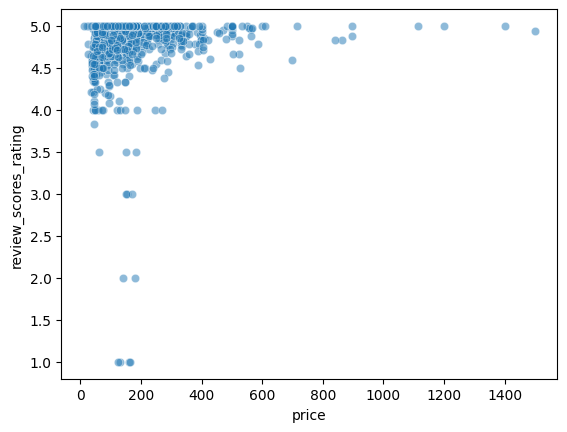

In [14]:
sns.scatterplot(
    data=airbnb,
    x="price",
    y="review_scores_rating",
    alpha=0.5 # Ajusta la transparencia de los puntos para mejorar la visibilidad
)

plt.show()

¿Qué pasaría si quitamos temporalmente los precios extremadamente altos?

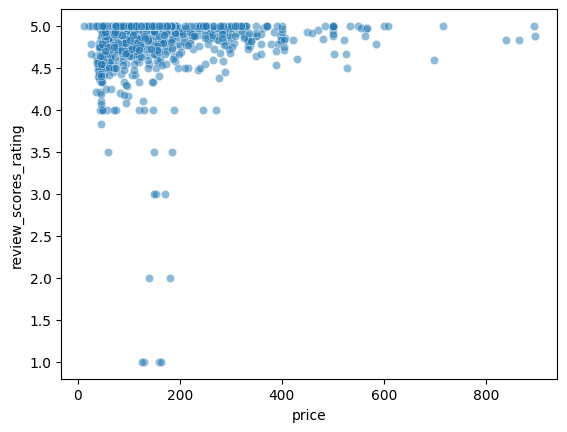

In [15]:
airbnb_grafica = airbnb[
    (airbnb["price"] <= 1000) &
    (airbnb["review_scores_rating"].notna())
]
sns.scatterplot(
    data=airbnb_grafica,
    x="price",
    y="review_scores_rating",
    alpha=0.5
)

plt.show()

 Relación entre número de reseñas y calificación promedio

In [16]:
df_review_count = airbnb.groupby('number_of_reviews')['review_scores_rating'].mean().reset_index().sort_values(by='number_of_reviews', ascending=False)

print(df_review_count.head(20))  # Mostrar los 20 valores con más reseñas


     number_of_reviews  review_scores_rating
235                967              4.870000
234                922              4.850000
233                911              4.790000
232                731              4.920000
231                666              4.850000
230                654              4.790000
229                641              4.470000
228                634              4.860000
227                551              4.930000
226                539              4.900000
225                514              4.940000
224                512              4.940000
223                511              4.710000
222                498              4.860000
221                456              4.860000
220                437              4.850000
219                436              4.790000
218                434              4.906667
217                426              4.920000
216                424              4.810000


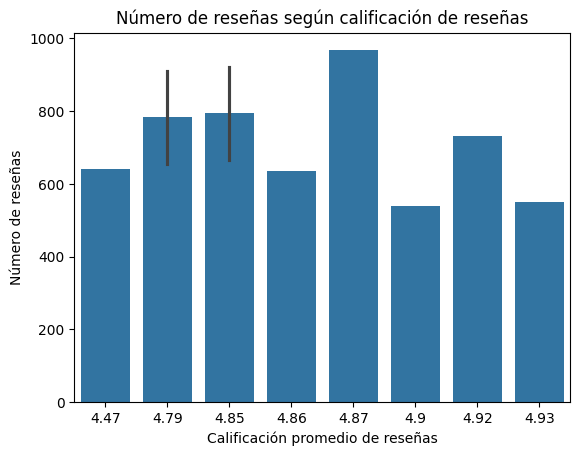

In [17]:
sns.barplot(
    data=df_review_count.head(10),  # Mostrar solo los 20 valores con más reseñas
    x='review_scores_rating',
    y='number_of_reviews'
)

plt.xlabel("Calificación promedio de reseñas")
plt.ylabel("Número de reseñas")
plt.title("Número de reseñas según calificación de reseñas")
plt.show()